# 🌾 Seasonal Agriculture Performance Analysis

### Major Project – VOIS AICTE Batch 1 2026–2027

**Project Type:** Data Analytics  
**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn, SciPy, Scikit-learn

---

## Project Overview

This project analyzes agricultural performance across different seasons
to identify patterns, trends, relationships and differences in crop
production, resource usage, environmental conditions and economic outcomes.

## 1. Problem Statement

Agricultural performance is influenced by seasonal variations in
environmental conditions, farming practices, resource availability and
economic factors.

The objective of this project is to analyze the agricultural dataset
and investigate how agricultural performance differs across Kharif,
Rabi and Zaid seasons.

The analysis focuses on identifying meaningful patterns, trends,
relationships, variations and unusual observations that can support
better seasonal agricultural planning.


## 2. Objectives

The main objectives of this project are:

1. Understand the agricultural dataset.
2. Clean and prepare the data for analysis.
3. Analyze agricultural performance across seasons.
4. Identify important seasonal patterns and trends.
5. Compare crop performance across seasons.
6. Analyze resource usage across seasons.
7. Investigate relationships between environmental conditions
   and agricultural outcomes.
8. Analyze economic performance across seasons.
9. Identify unusual or significant patterns.
10. Develop evidence-based recommendations.

## 3. Analytical Questions

This project investigates the following questions:

1. How does agricultural yield vary across Kharif, Rabi and Zaid seasons?

2. Which season provides the highest average profit per hectare?

3. How does water efficiency differ across seasons?

4. How does disease and pest risk vary between seasons?

5. Which crops perform best economically in each season?

6. How does agricultural performance differ across states?

7. What relationships exist between environmental conditions
   and agricultural yield?

8. Does irrigation method influence yield, profit and water efficiency?

9. Are the observed differences between seasons statistically significant?

10. Which factors are most useful for predicting agricultural yield?

## 4. Dataset Description

The dataset contains **4,000 farm-level records and 28 variables** covering agricultural conditions, farming practices, crop performance, resource usage, environmental factors and economic outcomes.

Key groups of variables include:
- **Location:** State and District
- **Crop and season:** Crop and Season
- **Farm characteristics:** Farm area
- **Environmental conditions:** Rainfall, temperature, humidity, sunlight, soil pH and soil moisture
- **Resources and practices:** NPK nutrients, irrigation method, fertilizer, pesticide and seed quality
- **Outcomes:** Yield, production, market price, cost, revenue, profit and water efficiency
- **Risk:** Disease and pest risk

The analysis focuses on the three seasons present in the project dataset: **Kharif, Rabi and Zaid**.


## 5. Import Libraries and Load Dataset

The following cells import the required Python libraries and load the agricultural dataset into a Pandas DataFrame.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from itertools import combinations

try:
    from IPython.display import display
except ImportError:
    display = print

sns.set_theme(style="whitegrid", palette="Set2")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

OUT_DIR = Path("seasonal_agriculture_outputs")
OUT_DIR.mkdir(exist_ok=True)

CSV_PATH = "seasonal_agriculture_performance_dataset.csv"
URL = "https://www.genspark.ai/api/files/s/QT9dvqCH"

try:
    df_raw = pd.read_csv(CSV_PATH)
except FileNotFoundError:
    df_raw = pd.read_csv(URL)

df = df_raw.copy()

print("Dataset shape:", df.shape)
display(df.head())
df.info()


Dataset shape: (4000, 28)


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

## 6. Data Understanding

The dataset is examined for column names, data types, descriptive statistics and missing values before cleaning.


In [2]:
print("Columns:")
display(pd.DataFrame(df.columns, columns=["Column_Name"]))

missing_report = pd.DataFrame({
    "Missing_Count": df.isna().sum(),
    "Missing_Percentage": (df.isna().mean() * 100).round(2)
}).sort_values("Missing_Count", ascending=False)

display(missing_report)

display(df.describe(include="all").T)


Columns:


,Column_Name
0,Farm_ID
1,State
2,District
3,Crop
4,Season
5,Farm_Area_Hectares
6,Rainfall_mm
7,Avg_Temperature_C
8,Humidity_pct
9,Sunlight_Hours_Day


,Missing_Count,Missing_Percentage
Rainfall_mm,48,1.2
Soil_Moisture_pct,40,1.0
Yield_Tonnes_Ha,32,0.8
Farm_ID,0,0.0
Crop,0,0.0
District,0,0.0
Farm_Area_Hectares,0,0.0
Season,0,0.0
Avg_Temperature_C,0,0.0
Humidity_pct,0,0.0


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Farm_ID,4000,4000,SF13984,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
State,4000,8,Andhra Pradesh,529,NaN,NaN,NaN,NaN,NaN,NaN,NaN
District,4000,10,Ludhiana,427,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Crop,4000,8,Rice,690,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Season,4000,3,Kharif,1779,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Farm_Area_Hectares,4000.0,NaN,NaN,NaN,7.888265,4.223764,0.5,4.26,7.895,11.65,15.0
Rainfall_mm,3952.0,NaN,NaN,NaN,601.152657,288.925025,80.0,370.2,582.0,834.95,1395.2
Avg_Temperature_C,4000.0,NaN,NaN,NaN,26.8189,3.81818,16.2,23.9,26.9,29.6,39.7
Humidity_pct,4000.0,NaN,NaN,NaN,63.2105,11.960834,25.0,54.775,63.0,71.9,95.0
Sunlight_Hours_Day,4000.0,NaN,NaN,NaN,7.32305,1.121186,3.5,6.6,7.3,8.1,11.0


## 7. Data Cleaning

Duplicate records and duplicate Farm IDs are checked and removed where necessary. Missing values and data-quality issues are handled before analysis.


In [3]:
# Remove duplicate rows and duplicate Farm_ID records
print("Duplicate rows:", df.duplicated().sum())

df = df.drop_duplicates()

if "Farm_ID" in df.columns:
    print("Duplicate Farm_ID:", df.duplicated(subset=["Farm_ID"]).sum())
    df = df.drop_duplicates(subset=["Farm_ID"], keep="first")

# Identify categorical and numerical columns
categorical_cols = ["Farm_ID", "State", "District", "Crop", "Season", "Irrigation_Method"]
categorical_cols = [col for col in categorical_cols if col in df.columns]

numeric_cols = [col for col in df.columns if col not in categorical_cols]

# Clean categorical columns
for col in categorical_cols:
    df[col] = df[col].astype("string").str.strip()

if "Season" in df.columns:
    df["Season"] = df["Season"].str.title()

if "Irrigation_Method" in df.columns:
    df["Irrigation_Method"] = df["Irrigation_Method"].str.title()

# Convert numeric columns safely
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

missing_before = df.isna().sum()

# Basic range checks
range_rules = {
    "Farm_Area_Hectares": (0, 1000),
    "Rainfall_mm": (0, 3000),
    "Avg_Temperature_C": (0, 60),
    "Humidity_pct": (0, 100),
    "Sunlight_Hours_Day": (0, 16),
    "Soil_pH": (3, 10),
    "Soil_Moisture_pct": (0, 100),
    "Nitrogen_kg_ha": (0, 500),
    "Phosphorus_kg_ha": (0, 300),
    "Potassium_kg_ha": (0, 400),
    "Fertilizer_kg_ha": (0, 1000),
    "Pesticide_Litre_ha": (0, 100),
    "Seed_Quality_Score": (0, 1),
    "Yield_Tonnes_Ha": (0, 200),
    "Production_Tonnes": (0, 10000),
    "Market_Price_INR_Tonne": (0, 500000),
    "Total_Cost_INR": (0, 10000000),
    "Revenue_INR": (0, 50000000),
    "Water_Used_m3": (0, 1000000),
    "Water_Efficiency_t_per_1000m3": (0, 500),
    "Disease_Pest_Risk_pct": (0, 100)
}

for col, (low, high) in range_rules.items():
    if col in df.columns:
        df.loc[~df[col].between(low, high), col] = np.nan

# Derive missing yield, production, revenue, and profit where possible
if {"Production_Tonnes", "Farm_Area_Hectares", "Yield_Tonnes_Ha"}.issubset(df.columns):
    calculated_yield = df["Production_Tonnes"] / df["Farm_Area_Hectares"]
    df["Yield_Tonnes_Ha"] = df["Yield_Tonnes_Ha"].fillna(calculated_yield)

if {"Farm_Area_Hectares", "Yield_Tonnes_Ha", "Production_Tonnes"}.issubset(df.columns):
    calculated_production = df["Farm_Area_Hectares"] * df["Yield_Tonnes_Ha"]
    df["Production_Tonnes"] = df["Production_Tonnes"].fillna(calculated_production)

if {"Production_Tonnes", "Market_Price_INR_Tonne", "Revenue_INR"}.issubset(df.columns):
    calculated_revenue = df["Production_Tonnes"] * df["Market_Price_INR_Tonne"]
    df["Revenue_INR"] = df["Revenue_INR"].fillna(calculated_revenue)

if {"Revenue_INR", "Total_Cost_INR", "Profit_INR"}.issubset(df.columns):
    calculated_profit = df["Revenue_INR"] - df["Total_Cost_INR"]
    df["Profit_INR"] = df["Profit_INR"].fillna(calculated_profit)

# Group-wise median imputation for remaining numerical missing values
group_cols = [col for col in ["Crop", "Season"] if col in df.columns]

for col in numeric_cols:
    if col in df.columns and df[col].isna().sum() > 0:
        if group_cols:
            df[col] = df[col].fillna(df.groupby(group_cols, observed=True)[col].transform("median"))
        if "Season" in df.columns:
            df[col] = df[col].fillna(df.groupby("Season", observed=True)[col].transform("median"))
        df[col] = df[col].fillna(df[col].median())

# Fill missing categorical values
for col in categorical_cols:
    df[col] = df[col].fillna("Unknown")

missing_after = df.isna().sum()

cleaning_report = pd.DataFrame({
    "Missing_Before": missing_before,
    "Missing_After": missing_after
}).fillna(0).astype(int)

display(cleaning_report[cleaning_report["Missing_Before"] > 0])
print("Cleaned dataset shape:", df.shape)


Duplicate rows: 0
Duplicate Farm_ID: 0


,Missing_Before,Missing_After
Rainfall_mm,48,0
Soil_Moisture_pct,40,0
Yield_Tonnes_Ha,32,0


Cleaned dataset shape: (4000, 28)


## 8. Feature Engineering

Additional measures are created to make comparisons fair across farms of different sizes, including cost per hectare, revenue per hectare, profit per hectare and water use per hectare.


In [4]:
def safe_divide(numerator, denominator):
    return numerator / denominator.replace(0, np.nan)

if {"Total_Cost_INR", "Farm_Area_Hectares"}.issubset(df.columns):
    df["Cost_per_Ha"] = safe_divide(df["Total_Cost_INR"], df["Farm_Area_Hectares"])

if {"Revenue_INR", "Farm_Area_Hectares"}.issubset(df.columns):
    df["Revenue_per_Ha"] = safe_divide(df["Revenue_INR"], df["Farm_Area_Hectares"])

if {"Profit_INR", "Farm_Area_Hectares"}.issubset(df.columns):
    df["Profit_per_Ha"] = safe_divide(df["Profit_INR"], df["Farm_Area_Hectares"])

if {"Profit_INR", "Revenue_INR"}.issubset(df.columns):
    df["Profit_Margin_pct"] = safe_divide(df["Profit_INR"], df["Revenue_INR"]) * 100

if {"Water_Used_m3", "Farm_Area_Hectares"}.issubset(df.columns):
    df["Water_m3_per_Ha"] = safe_divide(df["Water_Used_m3"], df["Farm_Area_Hectares"])

if {"Nitrogen_kg_ha", "Phosphorus_kg_ha", "Potassium_kg_ha"}.issubset(df.columns):
    df["Total_NPK_kg_ha"] = (
        df["Nitrogen_kg_ha"] +
        df["Phosphorus_kg_ha"] +
        df["Potassium_kg_ha"]
    )

if {"Fertilizer_kg_ha", "Yield_Tonnes_Ha"}.issubset(df.columns):
    df["Fertilizer_kg_per_Tonne_Yield"] = safe_divide(
        df["Fertilizer_kg_ha"], df["Yield_Tonnes_Ha"]
    )

if {"Pesticide_Litre_ha", "Yield_Tonnes_Ha"}.issubset(df.columns):
    df["Pesticide_L_per_Tonne_Yield"] = safe_divide(
        df["Pesticide_Litre_ha"], df["Yield_Tonnes_Ha"]
    )

if "Profit_INR" in df.columns:
    df["Is_Profitable"] = df["Profit_INR"] > 0

display(df.head())


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct,Cost_per_Ha,Revenue_per_Ha,Profit_per_Ha,Profit_Margin_pct,Water_m3_per_Ha,Total_NPK_kg_ha,Fertilizer_kg_per_Tonne_Yield,Pesticide_L_per_Tonne_Yield,Is_Profitable
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700.0,42662.0,30810.0,-11852,237.0,5.485,55.3,80494.339623,58132.075472,-22362.264151,-38.468030,447.169811,228.1,98.658537,1.760163,False
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613.0,492351.0,40401.0,-451950,4953.0,0.396,49.9,75398.315467,6186.983155,-69211.332312,-1118.660429,758.499234,239.3,904.666667,22.866667,False
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283.0,315210.0,190466.0,-124744,1275.0,1.984,33.7,64858.024691,39190.534979,-25667.489712,-65.494104,262.345679,287.9,312.692308,11.692308,False
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244.0,296444.0,200740.0,-95704,3834.0,2.160,50.6,65876.444444,44608.888889,-21267.555556,-47.675600,852.000000,309.7,99.021739,3.472826,False
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818.0,337959.0,193607.0,-144352,3287.0,2.829,32.3,80275.296912,45987.410926,-34287.885986,-74.559288,780.760095,314.5,110.814480,3.443439,False


## 9. Data Validation

Calculated production and other consistency checks are compared with the recorded values to identify potentially unrealistic or inconsistent observations.


In [5]:
validation_results = {}

if {"Farm_Area_Hectares", "Yield_Tonnes_Ha", "Production_Tonnes"}.issubset(df.columns):
    df["Calculated_Production"] = df["Farm_Area_Hectares"] * df["Yield_Tonnes_Ha"]
    df["Production_Diff_pct"] = (
        abs(df["Production_Tonnes"] - df["Calculated_Production"]) /
        df["Production_Tonnes"].replace(0, np.nan)
    ) * 100
    validation_results["Production difference > 2%"] = int((df["Production_Diff_pct"] > 2).sum())

if {"Production_Tonnes", "Market_Price_INR_Tonne", "Revenue_INR"}.issubset(df.columns):
    df["Calculated_Revenue"] = df["Production_Tonnes"] * df["Market_Price_INR_Tonne"]
    df["Revenue_Diff_pct"] = (
        abs(df["Revenue_INR"] - df["Calculated_Revenue"]) /
        df["Revenue_INR"].replace(0, np.nan)
    ) * 100
    validation_results["Revenue difference > 2%"] = int((df["Revenue_Diff_pct"] > 2).sum())

if {"Revenue_INR", "Total_Cost_INR", "Profit_INR"}.issubset(df.columns):
    df["Calculated_Profit"] = df["Revenue_INR"] - df["Total_Cost_INR"]
    df["Profit_Diff"] = abs(df["Profit_INR"] - df["Calculated_Profit"])
    validation_results["Profit difference > INR 10"] = int((df["Profit_Diff"] > 10).sum())

display(pd.DataFrame(validation_results.items(), columns=["Check", "Count"]))


,Check,Count
0,Production difference > 2%,1
1,Revenue difference > 2%,0
2,Profit difference > INR 10,0


## 10. Seasonal Performance Analysis

This section compares the main agricultural and economic indicators across Kharif, Rabi and Zaid seasons.


In [6]:
season_order = ["Kharif", "Rabi", "Zaid"]

seasonal_summary = (
    df.groupby("Season", observed=True)
    .agg(
        Farms=("Farm_ID", "count"),
        Avg_Farm_Area_Ha=("Farm_Area_Hectares", "mean"),
        Avg_Yield_t_ha=("Yield_Tonnes_Ha", "mean"),
        Median_Yield_t_ha=("Yield_Tonnes_Ha", "median"),
        Total_Production_tonnes=("Production_Tonnes", "sum"),
        Avg_Revenue_INR=("Revenue_INR", "mean"),
        Avg_Cost_INR=("Total_Cost_INR", "mean"),
        Avg_Profit_INR=("Profit_INR", "mean"),
        Median_Profit_INR=("Profit_INR", "median"),
        Avg_Profit_per_Ha_INR=("Profit_per_Ha", "mean"),
        Profitable_Farms_pct=("Is_Profitable", lambda x: x.mean() * 100),
        Avg_Water_Used_m3=("Water_Used_m3", "mean"),
        Avg_Water_m3_per_Ha=("Water_m3_per_Ha", "mean"),
        Avg_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean"),
        Avg_Disease_Risk_pct=("Disease_Pest_Risk_pct", "mean"),
        Avg_Rainfall_mm=("Rainfall_mm", "mean"),
        Avg_Temperature_C=("Avg_Temperature_C", "mean"),
        Avg_Humidity_pct=("Humidity_pct", "mean"),
        Avg_Soil_Moisture_pct=("Soil_Moisture_pct", "mean"),
        Avg_Fertilizer_kg_ha=("Fertilizer_kg_ha", "mean"),
        Avg_Pesticide_L_ha=("Pesticide_Litre_ha", "mean")
    )
    .reindex(season_order)
)

display(seasonal_summary.round(2))
seasonal_summary.to_csv(OUT_DIR / "seasonal_summary.csv")


,Farms,Avg_Farm_Area_Ha,Avg_Yield_t_ha,Median_Yield_t_ha,Total_Production_tonnes,Avg_Revenue_INR,Avg_Cost_INR,Avg_Profit_INR,Median_Profit_INR,Avg_Profit_per_Ha_INR,Profitable_Farms_pct,Avg_Water_Used_m3,Avg_Water_m3_per_Ha,Avg_Water_Efficiency,Avg_Disease_Risk_pct,Avg_Rainfall_mm,Avg_Temperature_C,Avg_Humidity_pct,Avg_Soil_Moisture_pct,Avg_Fertilizer_kg_ha,Avg_Pesticide_L_ha
Season,,,,,,,,,,,,,,,,,,,,,
Kharif,1779,7.94,5.63,1.94,82387.61,710719.06,531804.41,178914.65,38808.0,21881.81,57.79,6102.20,758.17,5.89,54.47,852.10,28.45,71.81,31.20,187.08,5.08
Rabi,1627,7.75,5.09,1.66,67498.88,601526.05,513836.58,87689.47,-3187.0,10361.68,48.86,5846.99,763.36,5.19,40.48,435.95,23.49,57.89,24.05,185.41,5.02
Zaid,594,8.09,4.63,1.45,23098.35,519171.90,543976.73,-24804.82,-62144.0,-2636.52,35.52,6419.89,792.58,4.41,38.22,299.16,31.04,52.01,19.18,184.64,5.17


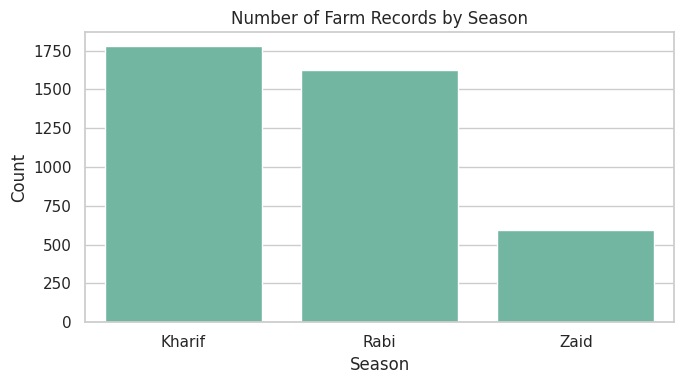

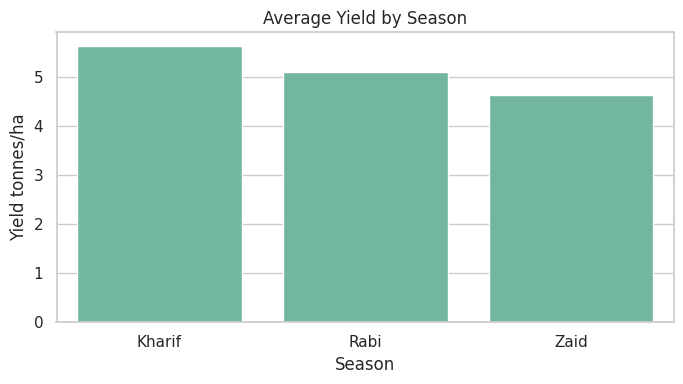

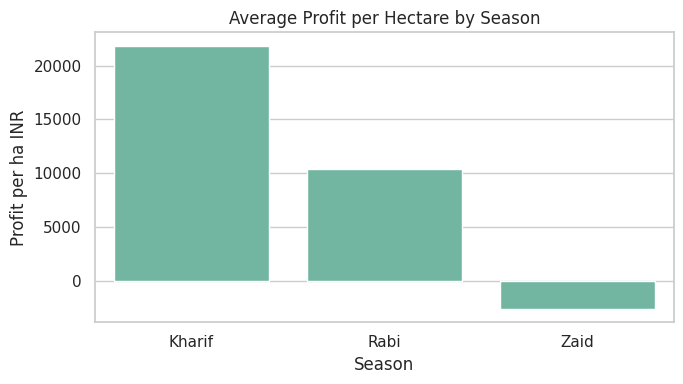

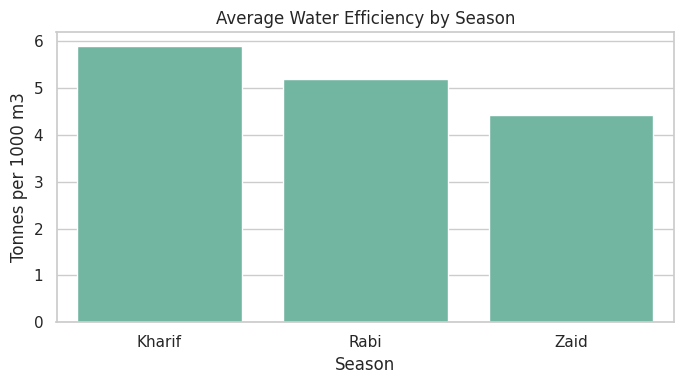

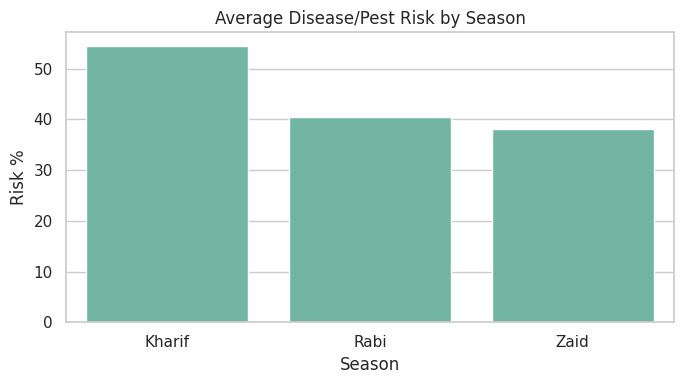

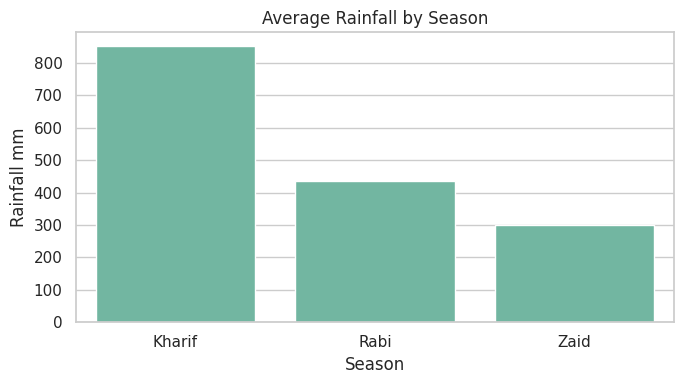

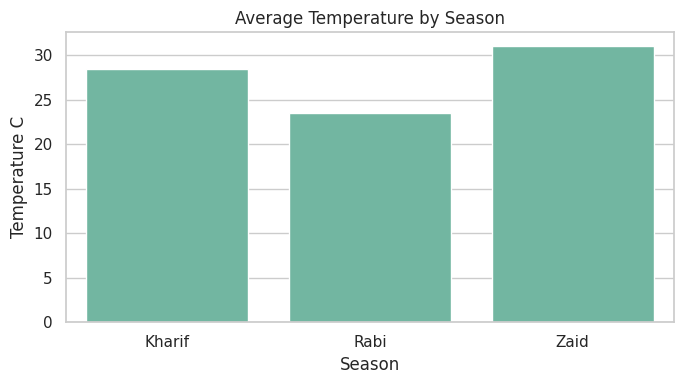

In [7]:
def save_plot(name):
    plt.tight_layout()
    plt.savefig(OUT_DIR / name, dpi=160, bbox_inches="tight")
    plt.show()

# Farm count by season
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="Season", order=season_order)
plt.title("Number of Farm Records by Season")
plt.xlabel("Season")
plt.ylabel("Count")
save_plot("farm_count_by_season.png")

metrics_to_plot = [
    ("Yield_Tonnes_Ha", "Average Yield by Season", "Yield tonnes/ha"),
    ("Profit_per_Ha", "Average Profit per Hectare by Season", "Profit per ha INR"),
    ("Water_Efficiency_t_per_1000m3", "Average Water Efficiency by Season", "Tonnes per 1000 m3"),
    ("Disease_Pest_Risk_pct", "Average Disease/Pest Risk by Season", "Risk %"),
    ("Rainfall_mm", "Average Rainfall by Season", "Rainfall mm"),
    ("Avg_Temperature_C", "Average Temperature by Season", "Temperature C")
]

for metric, title, ylabel in metrics_to_plot:
    temp = (
        df.groupby("Season", observed=True)[metric]
        .mean()
        .reindex(season_order)
        .reset_index()
    )

    plt.figure(figsize=(7, 4))
    sns.barplot(data=temp, x="Season", y=metric, order=season_order)
    plt.title(title)
    plt.xlabel("Season")
    plt.ylabel(ylabel)
    save_plot(f"{metric}_by_season.png")


### Statistical Interpretation

The statistical analysis indicates that seasonal differences are not
uniform across all agricultural metrics.

Profit per hectare and disease/pest risk show strong evidence of
differences between seasons. Pairwise comparisons were subsequently
used to identify which specific seasons differ from one another.

Statistical significance is evaluated using a 0.05 significance level.

## 13. Distribution and Variability Analysis

Boxplots are used to examine the distribution and variation of key agricultural metrics across seasons. This helps identify differences in central tendency and potential extreme observations.


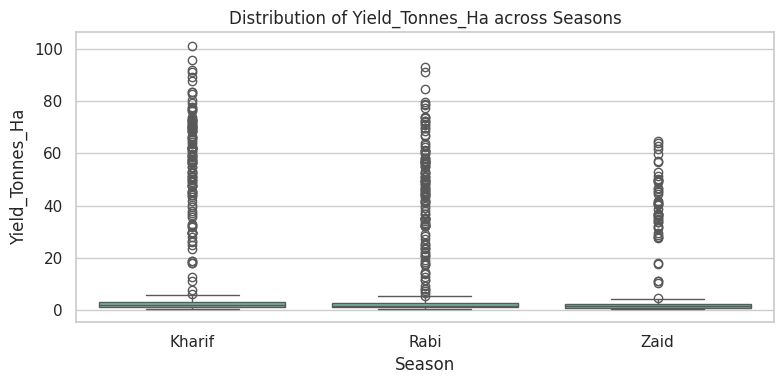

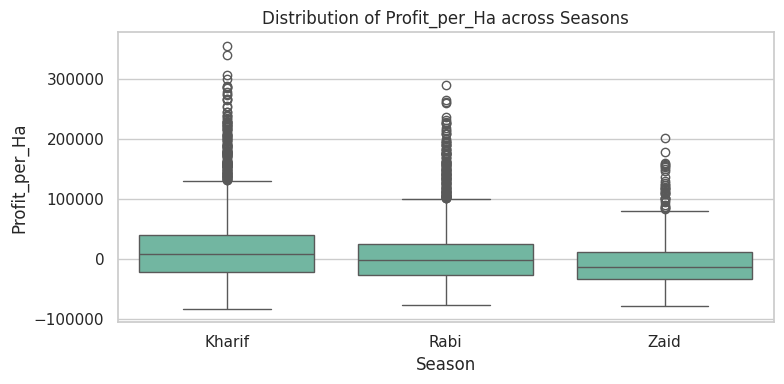

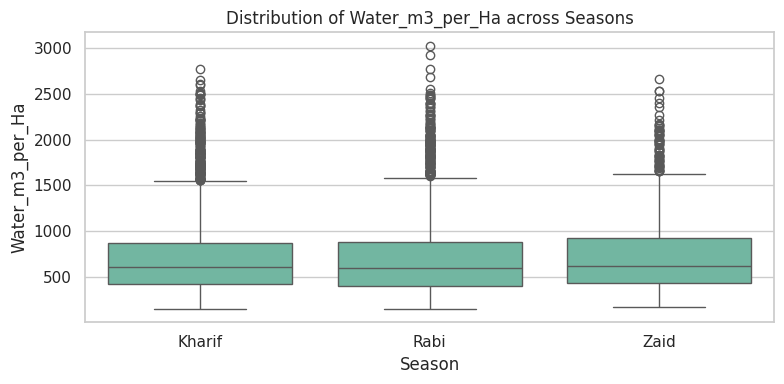

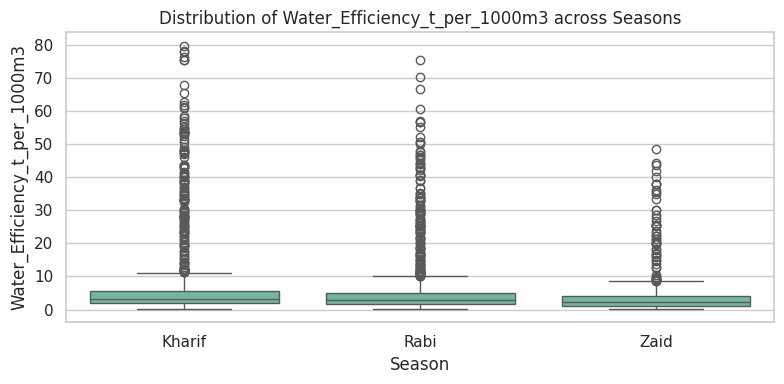

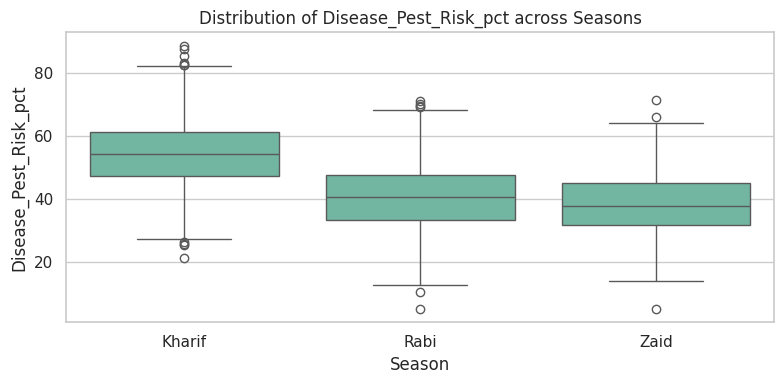

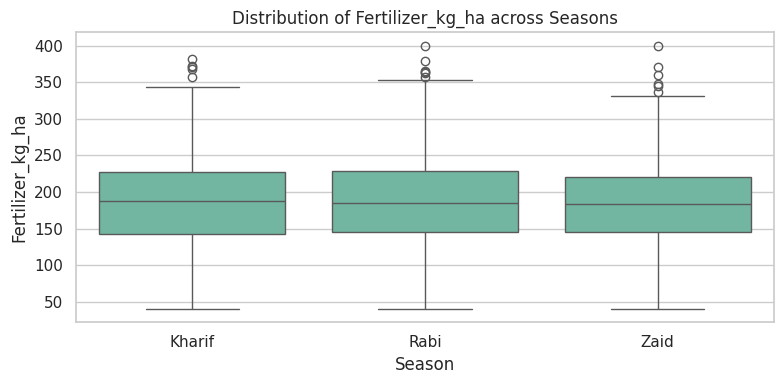

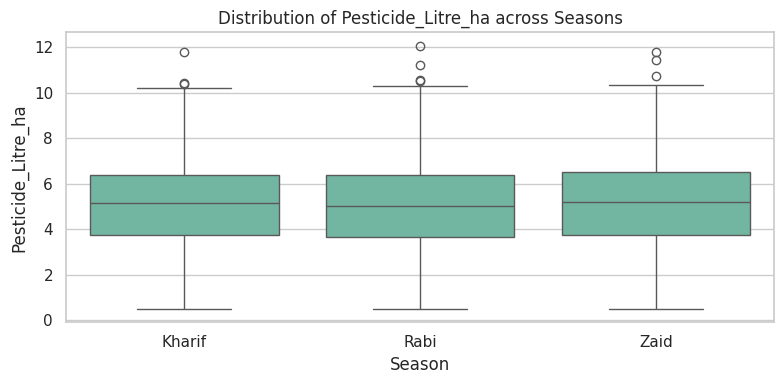

In [8]:
boxplot_metrics = [
    "Yield_Tonnes_Ha",
    "Profit_per_Ha",
    "Water_m3_per_Ha",
    "Water_Efficiency_t_per_1000m3",
    "Disease_Pest_Risk_pct",
    "Fertilizer_kg_ha",
    "Pesticide_Litre_ha"
]

for metric in boxplot_metrics:
    if metric in df.columns:
        plt.figure(figsize=(8, 4))
        sns.boxplot(data=df, x="Season", y=metric, order=season_order)
        plt.title(f"Distribution of {metric} across Seasons")
        plt.xlabel("Season")
        plt.ylabel(metric)
        save_plot(f"boxplot_{metric}_season.png")


## 14. Crop and Season Analysis

Crop-season combinations are compared to identify which crops perform better or worse under different seasonal conditions.


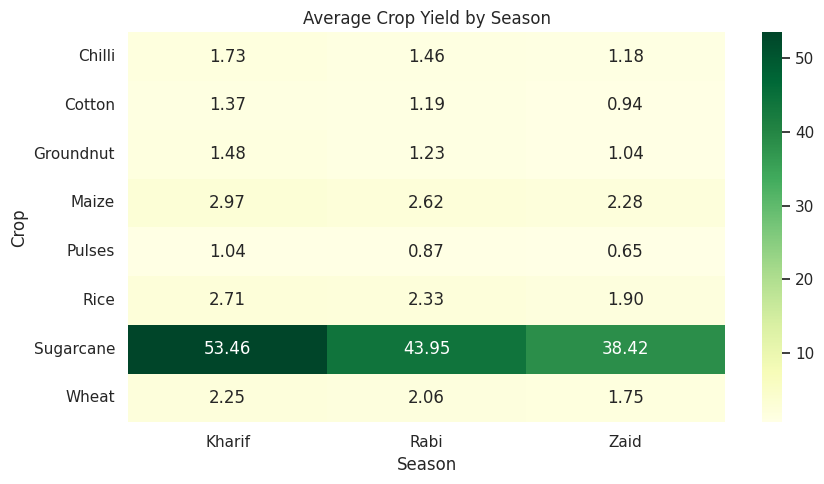

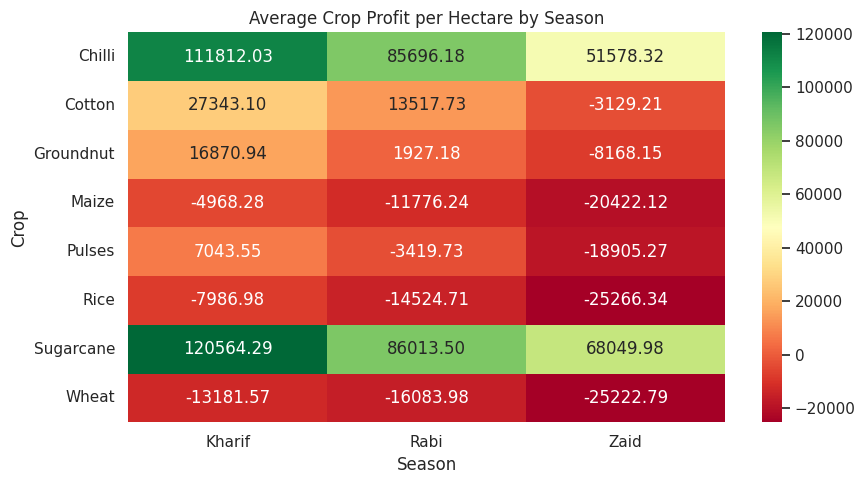

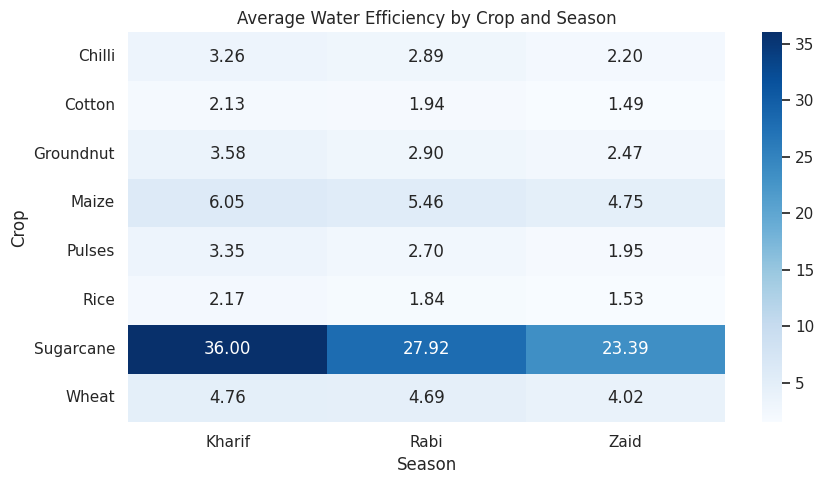

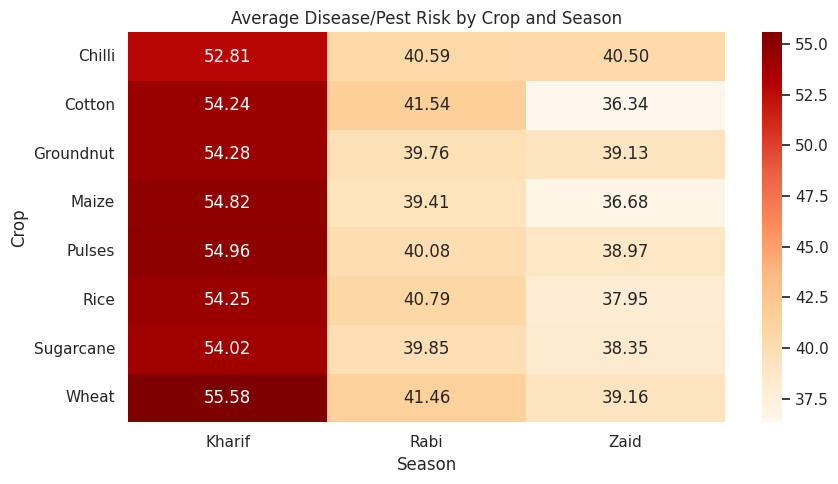

In [9]:
def plot_heatmap(metric, title, cmap="YlGnBu"):
    pivot = pd.pivot_table(
        df,
        index="Crop",
        columns="Season",
        values=metric,
        aggfunc="mean",
        observed=True
    ).reindex(columns=season_order)

    plt.figure(figsize=(9, 5))
    sns.heatmap(pivot, annot=True, fmt=".2f", cmap=cmap)
    plt.title(title)
    plt.xlabel("Season")
    plt.ylabel("Crop")
    save_plot(f"heatmap_{metric}.png")

plot_heatmap("Yield_Tonnes_Ha", "Average Crop Yield by Season", "YlGn")
plot_heatmap("Profit_per_Ha", "Average Crop Profit per Hectare by Season", "RdYlGn")
plot_heatmap("Water_Efficiency_t_per_1000m3", "Average Water Efficiency by Crop and Season", "Blues")
plot_heatmap("Disease_Pest_Risk_pct", "Average Disease/Pest Risk by Crop and Season", "OrRd")


## 15. State and Season Analysis

Agricultural performance is compared across states and seasons to identify regional differences in yield, profitability, water efficiency and disease/pest risk.


,State,Season,Farms,Avg_Yield_t_ha,Avg_Profit_per_Ha,Avg_Water_Efficiency,Avg_Disease_Risk
21,Telangana,Kharif,234,5.548589,26367.251301,5.832556,55.343590
6,Karnataka,Kharif,209,6.448031,24534.128264,5.887306,53.922967
3,Gujarat,Kharif,221,6.338416,23459.710044,6.384249,53.514932
0,Andhra Pradesh,Kharif,240,5.683165,22461.967583,6.115971,54.634583
18,Tamil Nadu,Kharif,206,5.520534,21938.434888,6.071316,55.077184
12,Maharashtra,Kharif,222,5.427516,21334.987926,5.634432,54.191441
16,Punjab,Rabi,186,8.609355,19378.271754,6.681602,40.475806
9,Madhya Pradesh,Kharif,226,5.992789,18836.117762,6.223460,54.776549
15,Punjab,Kharif,221,4.100633,16027.393690,4.975195,54.222172
13,Maharashtra,Rabi,218,5.501927,15329.412392,5.666628,41.398165


,State,Season,Farms,Avg_Yield_t_ha,Avg_Profit_per_Ha,Avg_Water_Efficiency,Avg_Disease_Risk
2,Andhra Pradesh,Zaid,85,4.445295,-8455.139017,4.071847,39.044706
5,Gujarat,Zaid,67,4.048209,-7456.246184,4.101537,37.008955
23,Telangana,Zaid,85,4.242469,-6288.344980,4.796541,39.137647
14,Maharashtra,Zaid,72,2.257771,-6241.890489,3.047681,37.772222
20,Tamil Nadu,Zaid,71,4.097746,-2531.732345,4.134028,39.370423
11,Madhya Pradesh,Zaid,63,5.456009,-580.012687,4.901810,40.731746
8,Karnataka,Zaid,74,6.623243,4903.044971,5.303757,37.085135
1,Andhra Pradesh,Rabi,204,3.470442,5638.944729,4.155319,40.606863
10,Madhya Pradesh,Rabi,208,3.746980,6132.197307,4.337476,40.643750
17,Punjab,Zaid,77,5.909610,6357.859956,4.916974,35.718182


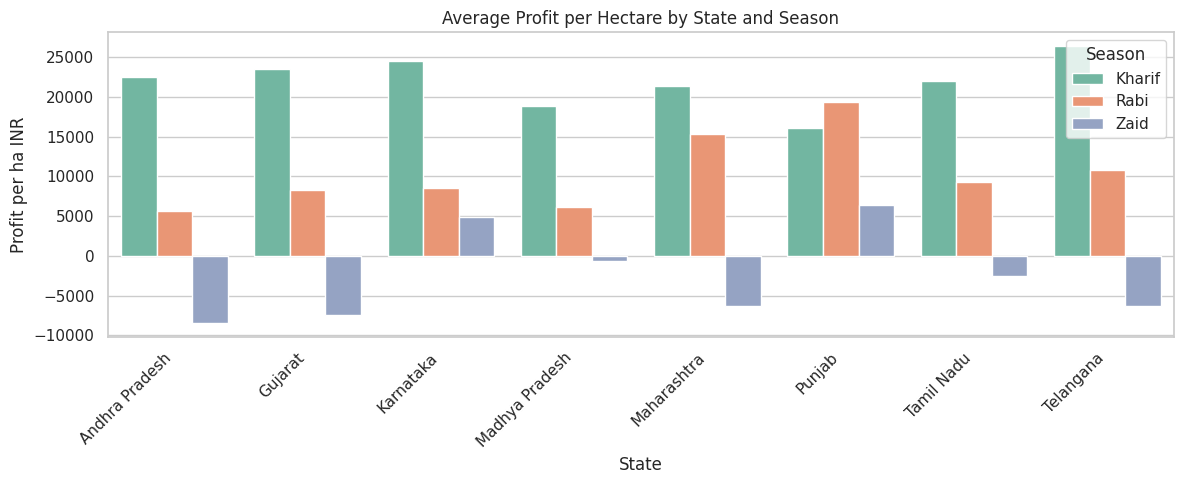

In [10]:
state_season_summary = (
    df.groupby(["State", "Season"], observed=True)
    .agg(
        Farms=("Farm_ID", "count"),
        Avg_Yield_t_ha=("Yield_Tonnes_Ha", "mean"),
        Avg_Profit_per_Ha=("Profit_per_Ha", "mean"),
        Avg_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean"),
        Avg_Disease_Risk=("Disease_Pest_Risk_pct", "mean")
    )
    .reset_index()
)

display(state_season_summary.sort_values("Avg_Profit_per_Ha", ascending=False).head(10))
display(state_season_summary.sort_values("Avg_Profit_per_Ha", ascending=True).head(10))

plt.figure(figsize=(12, 5))
sns.barplot(
    data=state_season_summary,
    x="State",
    y="Avg_Profit_per_Ha",
    hue="Season",
    hue_order=season_order
)
plt.title("Average Profit per Hectare by State and Season")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Profit per ha INR")
save_plot("state_season_profit_per_ha.png")


## 16. Resource and Irrigation Analysis

This section examines seasonal resource usage and compares irrigation methods using yield, profitability, water use per hectare and water efficiency.


,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha,Water_m3_per_Ha,Seed_Quality_Score
Season,,,,,,,
Kharif,120.02,58.10,105.30,187.08,5.08,758.17,0.82
Rabi,120.40,57.31,103.93,185.41,5.02,763.36,0.83
Zaid,120.53,58.13,105.42,184.64,5.17,792.58,0.82


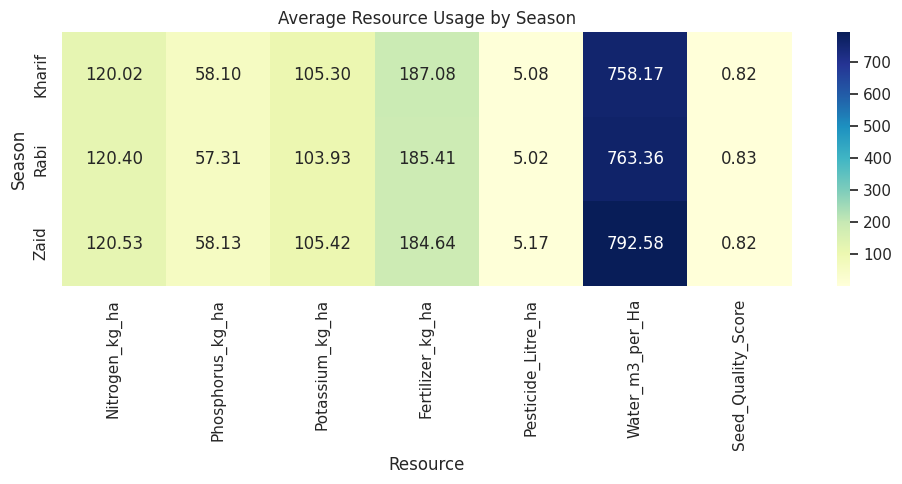

,Season,Irrigation_Method,Farms,Avg_Yield,Avg_Profit_per_Ha,Avg_Water_m3_per_Ha,Avg_Water_Efficiency
0,Kharif,Drip,405,7.26,36258.64,720.72,6.80
1,Kharif,Flood,590,4.98,16606.88,1009.04,3.64
2,Kharif,Rainfed,463,5.70,18086.67,465.50,8.85
3,Kharif,Sprinkler,321,4.67,18912.17,766.47,4.62
4,Rabi,Drip,370,6.35,22675.71,732.49,6.05
5,Rabi,Flood,526,5.06,6809.23,1045.30,3.48
6,Rabi,Rainfed,438,3.93,6450.40,428.38,6.87
7,Rabi,Sprinkler,293,5.30,7035.86,796.93,4.64
8,Zaid,Drip,140,5.85,2539.64,732.86,5.30
9,Zaid,Flood,194,3.97,-8936.95,1048.47,2.73


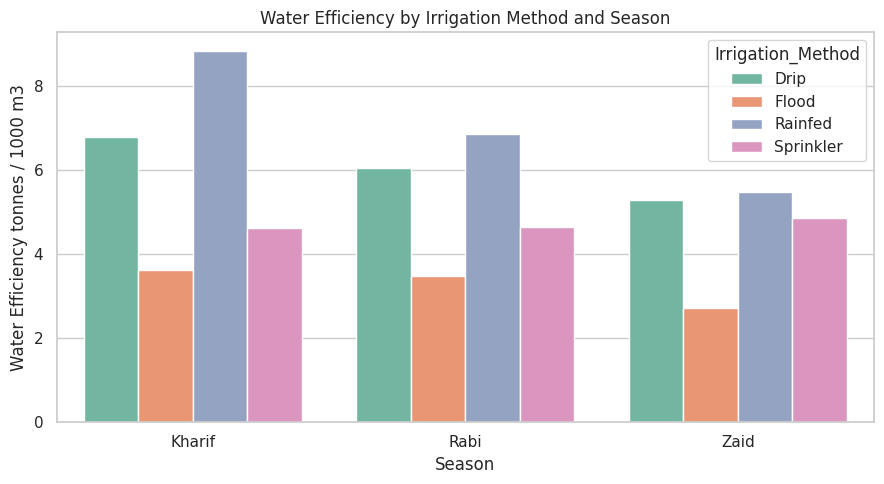

In [11]:
resource_cols = [
    "Nitrogen_kg_ha",
    "Phosphorus_kg_ha",
    "Potassium_kg_ha",
    "Fertilizer_kg_ha",
    "Pesticide_Litre_ha",
    "Water_m3_per_Ha",
    "Seed_Quality_Score"
]

resource_summary = (
    df.groupby("Season", observed=True)[resource_cols]
    .mean()
    .reindex(season_order)
)

display(resource_summary.round(2))

plt.figure(figsize=(10, 5))
sns.heatmap(resource_summary, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Average Resource Usage by Season")
plt.xlabel("Resource")
plt.ylabel("Season")
save_plot("resource_usage_by_season_heatmap.png")

irrigation_summary = (
    df.groupby(["Season", "Irrigation_Method"], observed=True)
    .agg(
        Farms=("Farm_ID", "count"),
        Avg_Yield=("Yield_Tonnes_Ha", "mean"),
        Avg_Profit_per_Ha=("Profit_per_Ha", "mean"),
        Avg_Water_m3_per_Ha=("Water_m3_per_Ha", "mean"),
        Avg_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean")
    )
    .reset_index()
)

display(irrigation_summary.round(2))

plt.figure(figsize=(9, 5))
sns.barplot(
    data=irrigation_summary,
    x="Season",
    y="Avg_Water_Efficiency",
    hue="Irrigation_Method",
    order=season_order
)
plt.title("Water Efficiency by Irrigation Method and Season")
plt.ylabel("Water Efficiency tonnes / 1000 m3")
save_plot("irrigation_water_efficiency_by_season.png")


## 17. Environmental Analysis

Environmental conditions and their relationships with agricultural outcomes are examined using correlations and scatter plots.


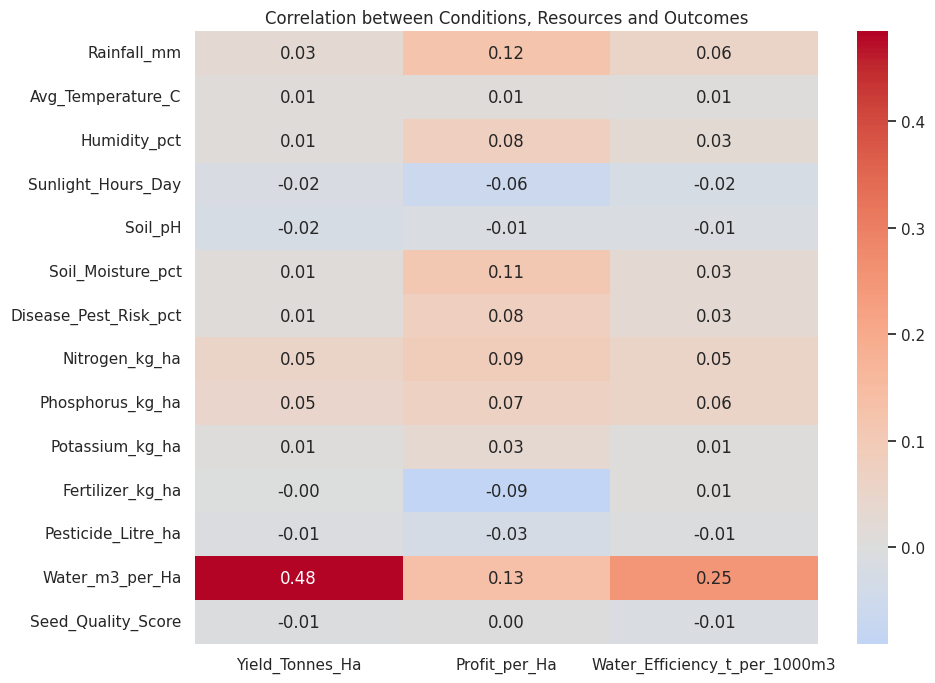

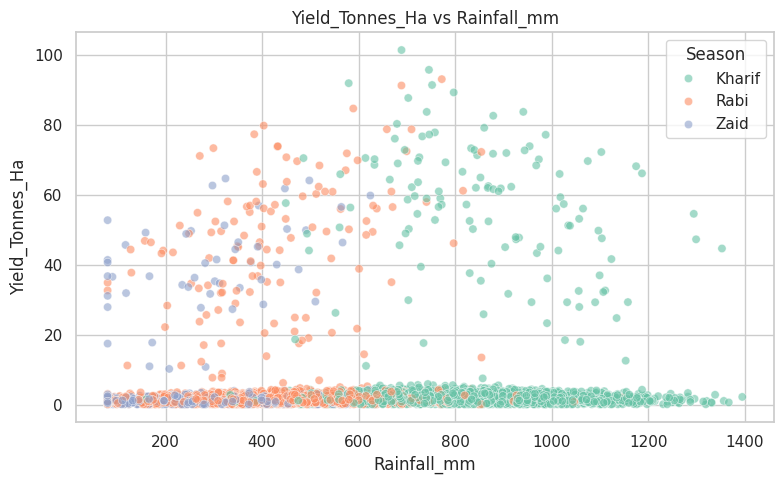

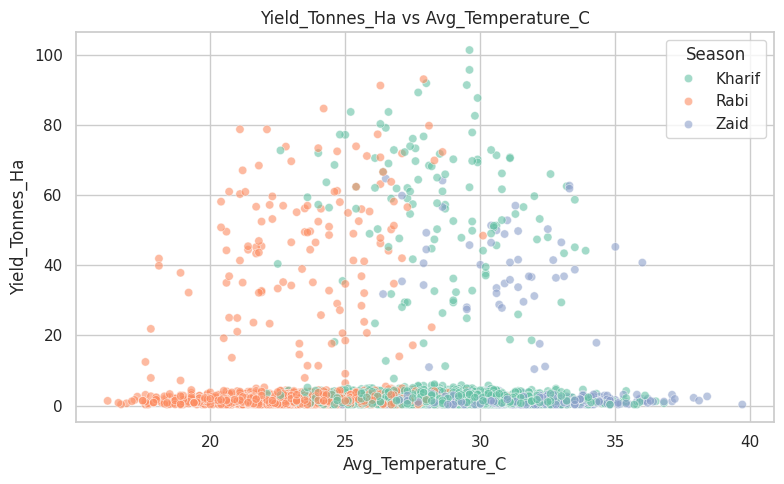

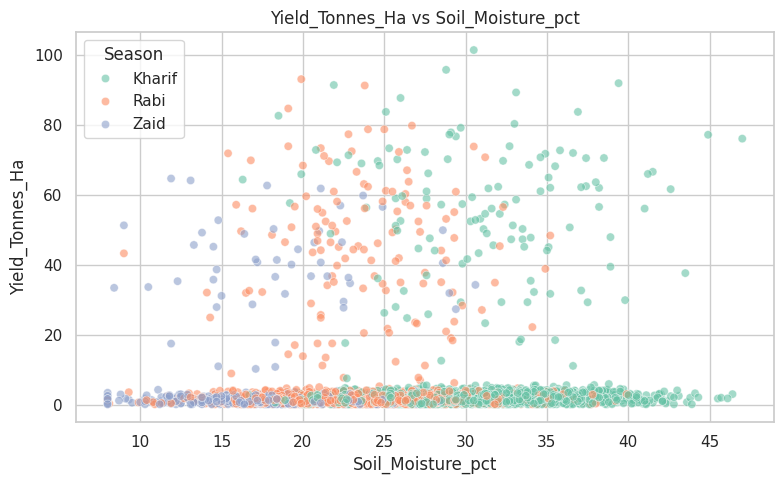

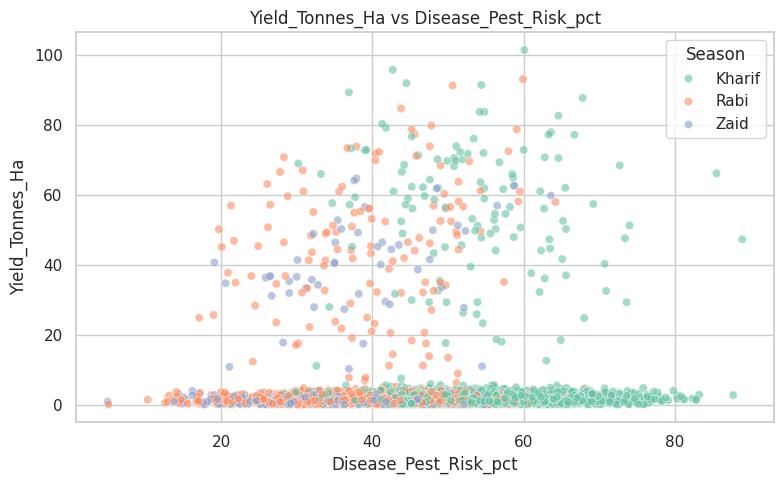

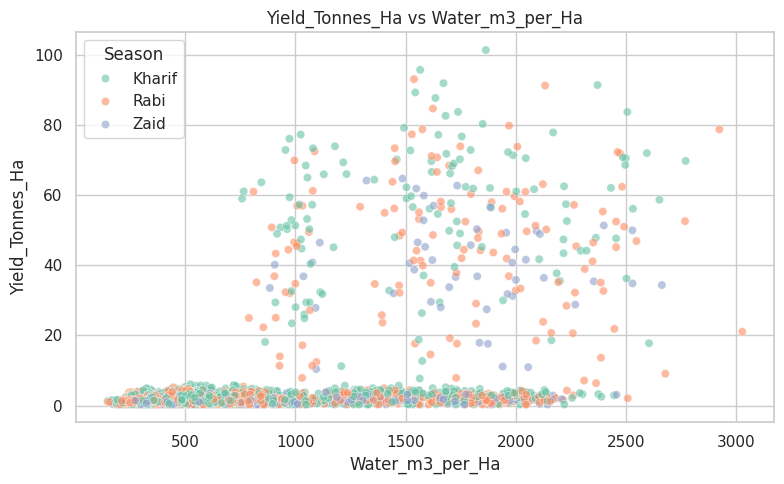

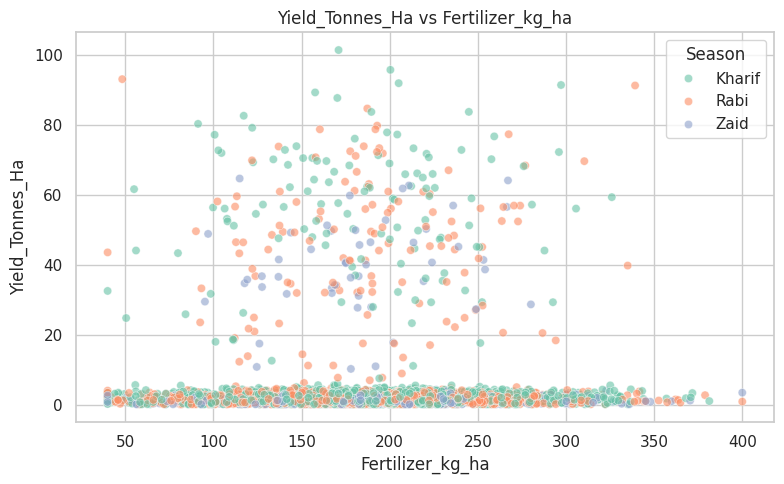

In [12]:
environment_cols = [
    "Rainfall_mm",
    "Avg_Temperature_C",
    "Humidity_pct",
    "Sunlight_Hours_Day",
    "Soil_pH",
    "Soil_Moisture_pct",
    "Disease_Pest_Risk_pct"
]

outcome_cols = [
    "Yield_Tonnes_Ha",
    "Profit_per_Ha",
    "Water_Efficiency_t_per_1000m3"
]

corr_matrix = df[environment_cols + resource_cols + outcome_cols].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(
    corr_matrix.loc[environment_cols + resource_cols, outcome_cols],
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Correlation between Conditions, Resources and Outcomes")
save_plot("correlation_conditions_resources_outcomes.png")

scatter_pairs = [
    ("Rainfall_mm", "Yield_Tonnes_Ha"),
    ("Avg_Temperature_C", "Yield_Tonnes_Ha"),
    ("Soil_Moisture_pct", "Yield_Tonnes_Ha"),
    ("Disease_Pest_Risk_pct", "Yield_Tonnes_Ha"),
    ("Water_m3_per_Ha", "Yield_Tonnes_Ha"),
    ("Fertilizer_kg_ha", "Yield_Tonnes_Ha")
]

for x, y in scatter_pairs:
    plt.figure(figsize=(8, 5))
    sns.scatterplot(data=df, x=x, y=y, hue="Season", alpha=0.6)
    plt.title(f"{y} vs {x}")
    save_plot(f"scatter_{x}_vs_{y}.png")


## 18. Statistical Testing

ANOVA and Kruskal-Wallis tests are used to evaluate whether seasonal differences are statistically meaningful. Eta-squared is also calculated as an effect-size measure.


In [13]:
from scipy import stats

def eta_squared(data, metric, group):
    grand_mean = data[metric].mean()
    ss_between = sum(
        len(g) * (g[metric].mean() - grand_mean) ** 2
        for _, g in data.groupby(group, observed=True)
    )
    ss_total = sum((data[metric] - grand_mean) ** 2)
    return ss_between / ss_total if ss_total != 0 else np.nan

test_metrics = [
    "Yield_Tonnes_Ha",
    "Profit_per_Ha",
    "Water_Efficiency_t_per_1000m3",
    "Disease_Pest_Risk_pct",
    "Water_m3_per_Ha",
    "Fertilizer_kg_ha",
    "Pesticide_Litre_ha"
]

test_results = []

for metric in test_metrics:
    samples = [
        group[metric].dropna()
        for _, group in df.groupby("Season", observed=True)
    ]

    if len(samples) >= 2 and min(len(s) for s in samples) > 2:
        anova_stat, anova_p = stats.f_oneway(*samples)
        kruskal_stat, kruskal_p = stats.kruskal(*samples)

        test_results.append({
            "Metric": metric,
            "ANOVA_p_value": anova_p,
            "Kruskal_p_value": kruskal_p,
            "Eta_Squared": eta_squared(df, metric, "Season"),
            "Significant_at_0.05": kruskal_p < 0.05
        })

test_results_df = pd.DataFrame(test_results)
display(test_results_df.sort_values("Kruskal_p_value"))


,Metric,ANOVA_p_value,Kruskal_p_value,Eta_Squared,Significant_at_0.05
3,Disease_Pest_Risk_pct,0.000000e+00,1.913429e-311,0.344317,True
1,Profit_per_Ha,2.127403e-19,8.104553e-22,0.021283,True
0,Yield_Tonnes_Ha,2.316769e-01,4.507137e-16,0.000731,True
2,Water_Efficiency_t_per_1000m3,9.719377e-04,4.608332e-13,0.003465,True
4,Water_m3_per_Ha,3.569708e-01,1.964557e-01,0.000515,False
6,Pesticide_Litre_ha,2.939565e-01,3.063336e-01,0.000612,False
5,Fertilizer_kg_ha,5.979792e-01,5.886323e-01,0.000257,False


## 19. Pairwise Seasonal Comparisons

Where overall seasonal differences are identified, pairwise Mann-Whitney tests with Bonferroni adjustment are used to examine which season pairs differ.


In [14]:
pairwise_results = []

for metric in test_metrics:
    for s1, s2 in combinations(season_order, 2):
        group1 = df.loc[df["Season"] == s1, metric].dropna()
        group2 = df.loc[df["Season"] == s2, metric].dropna()

        if len(group1) > 2 and len(group2) > 2:
            stat, p_value = stats.mannwhitneyu(group1, group2, alternative="two-sided")
            pairwise_results.append({
                "Metric": metric,
                "Season_1": s1,
                "Season_2": s2,
                "p_value": p_value,
                "Bonferroni_Adjusted_p": min(p_value * 3, 1),
                "Significant": min(p_value * 3, 1) < 0.05
            })

pairwise_results_df = pd.DataFrame(pairwise_results)
display(pairwise_results_df.sort_values("Bonferroni_Adjusted_p").head(30))


,Metric,Season_1,Season_2,p_value,Bonferroni_Adjusted_p,Significant
9,Disease_Pest_Risk_pct,Kharif,Rabi,8.080232e-251,2.424070e-250,True
10,Disease_Pest_Risk_pct,Kharif,Zaid,3.681419e-165,1.104426e-164,True
4,Profit_per_Ha,Kharif,Zaid,1.080830e-20,3.242491e-20,True
1,Yield_Tonnes_Ha,Kharif,Zaid,1.453738e-15,4.361213e-15,True
7,Water_Efficiency_t_per_1000m3,Kharif,Zaid,2.558996e-13,7.676987e-13,True
5,Profit_per_Ha,Rabi,Zaid,7.355690e-09,2.206707e-08,True
3,Profit_per_Ha,Kharif,Rabi,1.772927e-08,5.318780e-08,True
0,Yield_Tonnes_Ha,Kharif,Rabi,3.417778e-07,1.025333e-06,True
11,Disease_Pest_Risk_pct,Rabi,Zaid,2.591548e-06,7.774645e-06,True
8,Water_Efficiency_t_per_1000m3,Rabi,Zaid,3.540171e-06,1.062051e-05,True


## 20. Machine Learning: Yield Prediction

A Random Forest regression model is used to evaluate how well the available farm, environmental, resource, crop and seasonal variables can predict yield. Feature importance is interpreted as **predictive importance, not causation**.


Yield Prediction Model
R2 Score: 0.967
MAE: 0.738


,Feature,Importance
39,cat__Crop_Sugarcane,0.811587
5,num__Soil_pH,0.137440
1,num__Rainfall_mm,0.020222
7,num__Nitrogen_kg_ha,0.006303
2,num__Avg_Temperature_C,0.003187
44,cat__Irrigation_Method_Drip,0.001786
10,num__Fertilizer_kg_ha,0.001547
3,num__Humidity_pct,0.001533
4,num__Sunlight_Hours_Day,0.001460
6,num__Soil_Moisture_pct,0.001406


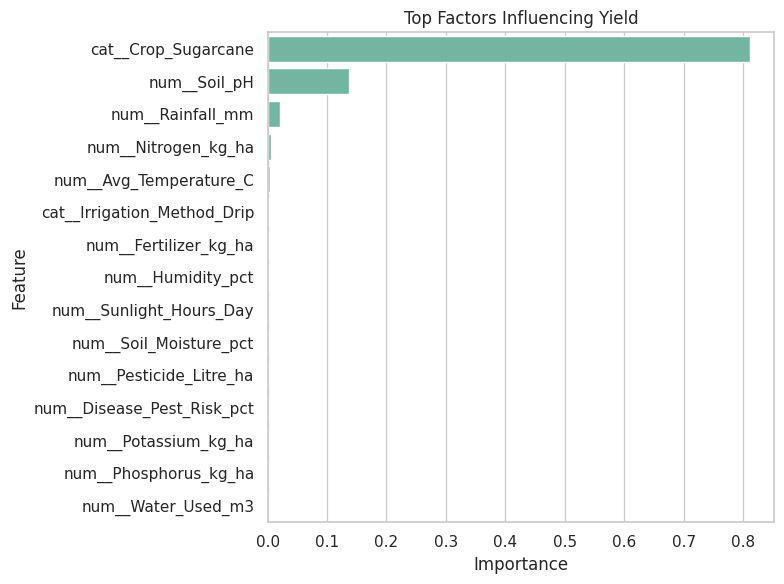

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

target = "Yield_Tonnes_Ha"

feature_cols = [
    "State",
    "District",
    "Crop",
    "Season",
    "Farm_Area_Hectares",
    "Rainfall_mm",
    "Avg_Temperature_C",
    "Humidity_pct",
    "Sunlight_Hours_Day",
    "Soil_pH",
    "Soil_Moisture_pct",
    "Nitrogen_kg_ha",
    "Phosphorus_kg_ha",
    "Potassium_kg_ha",
    "Irrigation_Method",
    "Fertilizer_kg_ha",
    "Pesticide_Litre_ha",
    "Seed_Quality_Score",
    "Water_Used_m3",
    "Disease_Pest_Risk_pct"
]

feature_cols = [col for col in feature_cols if col in df.columns]

X = df[feature_cols]
y = df[target]

cat_features = X.select_dtypes(include=["object", "string", "category"]).columns.tolist()
num_features = [col for col in X.columns if col not in cat_features]

try:
    encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), num_features),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", encoder)
        ]), cat_features)
    ]
)

model = Pipeline([
    ("preprocess", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        min_samples_leaf=3,
        n_jobs=-1
    ))
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Yield Prediction Model")
print("R2 Score:", round(r2_score(y_test, pred), 3))
print("MAE:", round(mean_absolute_error(y_test, pred), 3))

# Feature importance
try:
    feature_names = model.named_steps["preprocess"].get_feature_names_out()
    importances = model.named_steps["model"].feature_importances_

    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    }).sort_values("Importance", ascending=False)

    display(importance_df.head(20))

    plt.figure(figsize=(8, 6))
    sns.barplot(data=importance_df.head(15), x="Importance", y="Feature")
    plt.title("Top Predictive Features for Yield")
    save_plot("yield_feature_importance.png")

except Exception as e:
    print("Could not extract feature names:", e)


## 21. Additional Decision-Oriented Analysis

The following analyses provide practical insights for agricultural planning, including crop-season profitability, environmental risk, profit margin and seasonal resource requirements.


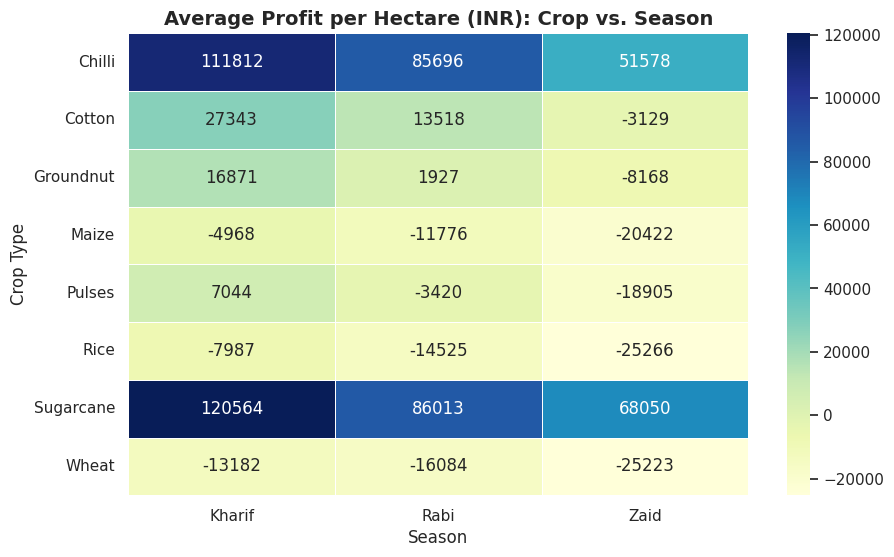

In [18]:
# Calculate Profit per Hectare for fair comparison
# Use the already-created Profit_per_Ha metric for a consistent per-hectare comparison
crop_season_profit = df.pivot_table(index='Crop', columns='Season', values='Profit_per_Ha', aggfunc='mean')

# Visualize with a Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(crop_season_profit, annot=True, fmt=".0f", cmap="YlGnBu", linewidths=.5)
plt.title('Average Profit per Hectare (INR): Crop vs. Season', fontsize=14, fontweight='bold')
plt.ylabel('Crop Type')
plt.xlabel('Season')
plt.show()

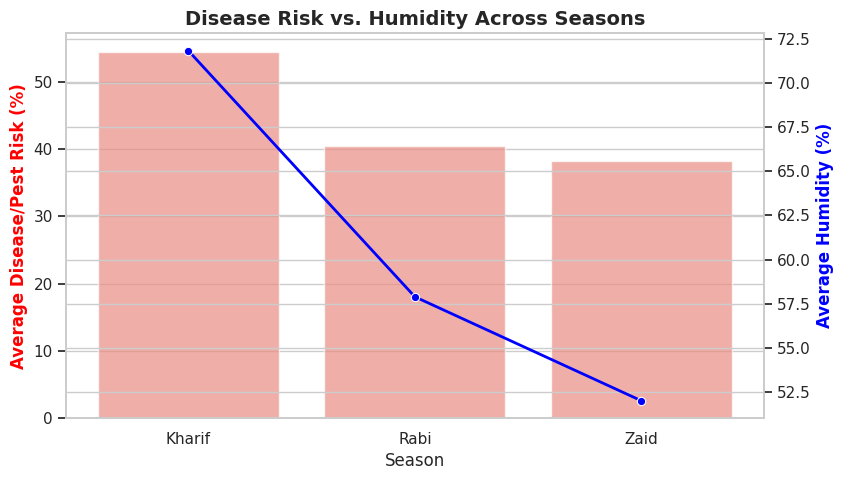

In [19]:
# Group by season to compare environmental factors with disease risk
environmental_risk = df.groupby('Season')[['Rainfall_mm', 'Humidity_pct', 'Disease_Pest_Risk_pct']].mean().reset_index()

# Plotting the relationship
fig, ax1 = plt.subplots(figsize=(9, 5))

# Bar chart for Disease Risk
sns.barplot(data=environmental_risk, x='Season', y='Disease_Pest_Risk_pct', color='salmon', alpha=0.7, ax=ax1)
ax1.set_ylabel('Average Disease/Pest Risk (%)', color='red', fontweight='bold')

# Line chart for Humidity on a secondary Y-axis
ax2 = ax1.twinx()
sns.lineplot(data=environmental_risk, x='Season', y='Humidity_pct', marker='o', color='blue', linewidth=2, ax=ax2)
ax2.set_ylabel('Average Humidity (%)', color='blue', fontweight='bold')

plt.title('Disease Risk vs. Humidity Across Seasons', fontsize=14, fontweight='bold')
plt.show()

--- Crop Performance & Water Usage Analysis ---


,Production_Tonnes,Water_Used_m3,Total_Cost_INR,Profit_Margin_pct
Crop,,,,
Sugarcane,392.41,13897.70,554792.13,27.35
Rice,19.29,10920.22,525828.76,-99.37
Cotton,9.40,5410.86,514876.17,-8.23
Chilli,12.38,4577.47,525898.89,33.78
Maize,21.78,4377.78,541046.32,-81.54
Wheat,16.85,4054.40,523503.22,-91.70
Groundnut,9.66,3459.54,498077.38,-28.66
Pulses,7.40,2833.67,532703.92,-36.48


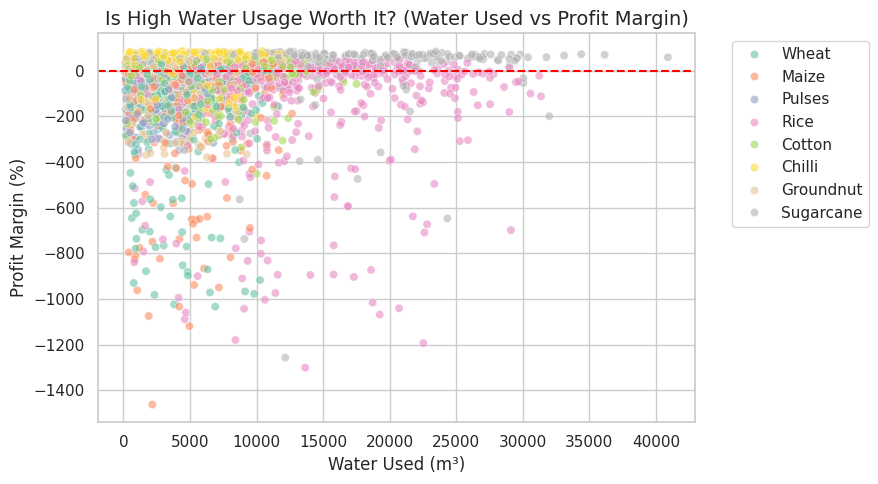

In [20]:
# Calculate Profit Margin (Profit as a percentage of Revenue)
df['Profit_Margin_pct'] = (df['Profit_INR'] / df['Revenue_INR']) * 100

# Analyze metrics by Crop type, sorted by Water Usage
crop_metrics = df.groupby('Crop').agg({
    'Production_Tonnes': 'mean',
    'Water_Used_m3': 'mean',
    'Total_Cost_INR': 'mean',
    'Profit_Margin_pct': 'mean'
}).sort_values(by='Water_Used_m3', ascending=False).round(2)

print("--- Crop Performance & Water Usage Analysis ---")
display(crop_metrics)

# Scatter plot: Water Used vs. Profit Margin for specific crops
plt.figure(figsize=(9, 5))
sns.scatterplot(data=df, x='Water_Used_m3', y='Profit_Margin_pct', hue='Crop', alpha=0.6)
plt.axhline(0, color='red', linestyle='--') # Red line for break-even margin
plt.title('Is High Water Usage Worth It? (Water Used vs Profit Margin)', fontsize=14)
plt.xlabel('Water Used (m³)')
plt.ylabel('Profit Margin (%)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [21]:
# Calculate average resource usage per hectare to help farmers plan inventory
resource_planning = df.groupby('Season').agg({
    'Fertilizer_kg_ha': 'mean',
    'Pesticide_Litre_ha': 'mean',
    'Water_Used_m3': 'mean'
}).round(2)

resource_planning.rename(columns={
    'Fertilizer_kg_ha': 'Avg Fertilizer Needed (kg/ha)',
    'Pesticide_Litre_ha': 'Avg Pesticide Needed (L/ha)',
    'Water_Used_m3': 'Avg Water Required (m³)'
}, inplace=True)

print("--- Seasonal Resource Planning Guide ---")
display(resource_planning)

--- Seasonal Resource Planning Guide ---


,Avg Fertilizer Needed (kg/ha),Avg Pesticide Needed (L/ha),Avg Water Required (m³)
Season,,,
Kharif,187.08,5.08,6102.20
Rabi,185.41,5.02,5846.99
Zaid,184.64,5.17,6419.89


## 22. Key Findings

The findings below summarize the evidence generated by the analysis. The numerical results are taken from the seasonal summary and supporting analyses above.

### Main observations

- **Kharif shows the strongest overall performance** in the dataset, with the highest average yield and highest average profit per hectare among the three seasons.
- **Zaid shows comparatively weaker economic performance**, including a negative average profit per hectare.
- **Crop performance varies substantially by season**, meaning the best crop choice is not necessarily the same across Kharif, Rabi and Zaid.
- **Water efficiency differs across seasons and irrigation methods**, making water-use management an important planning consideration.
- **Disease and pest risk varies by season**, indicating that crop protection planning should account for seasonal conditions.
- **Regional differences are visible across states**, so a single agricultural strategy may not be equally suitable everywhere.
- **Environmental and resource variables show measurable relationships with agricultural outcomes**, although correlation should not be interpreted as proof of causation.
- **Statistical tests identify significant seasonal differences for several metrics**, providing evidence beyond visual comparisons.
- The Random Forest model shows strong predictive performance for yield, with **crop-related information contributing substantially to prediction**.


In [16]:
ss = seasonal_summary.reset_index()

print("AUTO-GENERATED SEASONAL FINDINGS")
print("-" * 60)

def print_best_worst(metric, label, unit=""):
    best = ss.loc[ss[metric].idxmax()]
    worst = ss.loc[ss[metric].idxmin()]

    print(f"{label}")
    print(f"  Highest: {best['Season']} = {best[metric]:,.2f} {unit}")
    print(f"  Lowest : {worst['Season']} = {worst[metric]:,.2f} {unit}")
    print()

print_best_worst("Avg_Yield_t_ha", "Average Yield", "tonnes/ha")
print_best_worst("Avg_Profit_per_Ha_INR", "Average Profit per Hectare", "INR/ha")
print_best_worst("Avg_Water_Efficiency", "Water Efficiency", "tonnes/1000 m3")
print_best_worst("Avg_Disease_Risk_pct", "Disease/Pest Risk", "%")
print_best_worst("Avg_Rainfall_mm", "Rainfall", "mm")
print_best_worst("Avg_Temperature_C", "Temperature", "°C")

crop_season_summary = (
    df.groupby(["Crop", "Season"], observed=True)
    .agg(
        Farms=("Farm_ID", "count"),
        Avg_Yield=("Yield_Tonnes_Ha", "mean"),
        Avg_Profit_per_Ha=("Profit_per_Ha", "mean"),
        Avg_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean"),
        Avg_Disease_Risk=("Disease_Pest_Risk_pct", "mean")
    )
    .reset_index()
)

print("Top 10 crop-season combinations by profit per hectare:")
display(
    crop_season_summary
    .sort_values("Avg_Profit_per_Ha", ascending=False)
    .head(10)
    .round(2)
)

print("Bottom 10 crop-season combinations by profit per hectare:")
display(
    crop_season_summary
    .sort_values("Avg_Profit_per_Ha", ascending=True)
    .head(10)
    .round(2)
)


AUTO-GENERATED SEASONAL FINDINGS
------------------------------------------------------------
Average Yield
  Highest: Kharif = 5.63 tonnes/ha
  Lowest : Zaid = 4.63 tonnes/ha

Average Profit per Hectare
  Highest: Kharif = 21,881.81 INR/ha
  Lowest : Zaid = -2,636.52 INR/ha

Water Efficiency
  Highest: Kharif = 5.89 tonnes/1000 m3
  Lowest : Zaid = 4.41 tonnes/1000 m3

Disease/Pest Risk
  Highest: Kharif = 54.47 %
  Lowest : Zaid = 38.22 %

Rainfall
  Highest: Kharif = 852.10 mm
  Lowest : Zaid = 299.16 mm

Temperature
  Highest: Zaid = 31.04 °C
  Lowest : Rabi = 23.49 °C

Top 10 crop-season combinations by profit per hectare:


,Crop,Season,Farms,Avg_Yield,Avg_Profit_per_Ha,Avg_Water_Efficiency,Avg_Disease_Risk
18,Sugarcane,Kharif,125,53.46,120564.29,36.00,54.02
0,Chilli,Kharif,185,1.73,111812.03,3.26,52.81
19,Sugarcane,Rabi,129,43.95,86013.50,27.92,39.85
1,Chilli,Rabi,163,1.46,85696.18,2.89,40.59
20,Sugarcane,Zaid,51,38.42,68049.98,23.39,38.35
2,Chilli,Zaid,64,1.18,51578.32,2.20,40.50
3,Cotton,Kharif,215,1.37,27343.10,2.13,54.24
6,Groundnut,Kharif,193,1.48,16870.94,3.58,54.28
4,Cotton,Rabi,201,1.19,13517.73,1.94,41.54
12,Pulses,Kharif,221,1.04,7043.55,3.35,54.96


Bottom 10 crop-season combinations by profit per hectare:


,Crop,Season,Farms,Avg_Yield,Avg_Profit_per_Ha,Avg_Water_Efficiency,Avg_Disease_Risk
17,Rice,Zaid,102,1.90,-25266.34,1.53,37.95
23,Wheat,Zaid,85,1.75,-25222.79,4.02,39.16
11,Maize,Zaid,84,2.28,-20422.12,4.75,36.68
14,Pulses,Zaid,62,0.65,-18905.27,1.95,38.97
22,Wheat,Rabi,237,2.06,-16083.98,4.69,41.46
16,Rice,Rabi,274,2.33,-14524.71,1.84,40.79
21,Wheat,Kharif,292,2.25,-13181.57,4.76,55.58
10,Maize,Rabi,233,2.62,-11776.24,5.46,39.41
8,Groundnut,Zaid,54,1.04,-8168.15,2.47,39.13
15,Rice,Kharif,314,2.71,-7986.98,2.17,54.25


## 23. Output Files

The cleaned dataset and selected analytical outputs are saved for reproducibility and future use.


In [17]:
df.to_csv(OUT_DIR / "cleaned_seasonal_agriculture_dataset.csv", index=False)

print("Cleaned data and output files saved in:", OUT_DIR)


Cleaned data and output files saved in: seasonal_agriculture_outputs


## 24. Recommendations

Based on the findings from the dataset, the following evidence-based recommendations are proposed:

### 1. Use season-specific crop planning
Crop selection should be evaluated separately for Kharif, Rabi and Zaid because yield and profitability vary across seasons.

### 2. Prioritize strong crop-season combinations
Crop-season combinations with consistently higher profit per hectare should be considered when planning cultivation, while low- or negative-profit combinations should be reviewed carefully before expansion.

### 3. Reassess Zaid-season economics
The comparatively weak and negative average profitability observed for Zaid suggests that crop choice, input costs, water requirements and market conditions should be examined before increasing cultivation during this season.

### 4. Improve water-use efficiency
Irrigation strategies should be evaluated using both water consumption and water efficiency rather than yield alone. Methods associated with better efficiency should be considered where they are suitable for the crop and local conditions.

### 5. Strengthen seasonal disease and pest management
Because disease and pest risk differs between seasons, monitoring and preventive measures should be intensified during higher-risk periods.

### 6. Adopt region-specific strategies
Differences between states and seasons indicate that agricultural planning should consider local environmental and production conditions rather than applying one uniform strategy.

### 7. Optimize resource allocation
Fertilizer, pesticide and water requirements should be planned using the seasonal resource analysis to reduce unnecessary input use and improve operational efficiency.

### 8. Use predictive analytics as a decision-support tool
The yield prediction model can be used as a supporting analytical tool to identify combinations of farm, crop, environmental and management characteristics associated with higher predicted yield. It should complement, not replace, agricultural expertise and field-level decisions.

### 9. Investigate unusual and negative outcomes
Very low-profit or unusual crop-season combinations should be examined further to determine whether the pattern is associated with environmental conditions, input costs, irrigation, market prices or data-quality issues.

### 10. Continue collecting higher-quality data
Future analysis would benefit from consistent, multi-year and region-specific data so that seasonal patterns can be validated over time and used for more reliable planning.


## 25. Conclusion

This project analyzed seasonal agricultural performance using exploratory data analysis, visualization, statistical testing and machine-learning techniques.

The analysis identified meaningful differences between Kharif, Rabi and Zaid in terms of yield, profitability, water efficiency, environmental conditions and disease/pest risk. Kharif demonstrated the strongest overall performance in the dataset, while Zaid showed comparatively weaker yield and negative average profitability per hectare.

The crop-season and regional analyses further showed that agricultural performance is not uniform across crops, seasons and locations. Resource and irrigation analysis also highlighted the importance of efficient input and water management. Statistical testing provided additional evidence that several seasonal differences are meaningful, while the predictive model demonstrated that the available variables can be used to predict yield with strong performance.

Overall, the project provides evidence-based insights that can support better seasonal crop selection, resource planning, irrigation management, risk monitoring and agricultural decision-making.
